## 1. Data Preparation

In [69]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from IPython.display import display
from sklearn.metrics import mutual_info_score, accuracy_score, precision_score,recall_score, f1_score 

In [70]:
data = 'data/telco_churn_rate.csv'
df = pd.read_csv(data)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [71]:
#mmake column names and values look uniform
df.columns =df.columns.str.lower().str.replace(' ', '_')
cat_column = list(df.select_dtypes('object').columns)
for col in cat_column:
    df[col] = df[col].str.lower().str.replace(' ','_')


In [72]:
#check data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null   object 


In [73]:
# Change datatype of seniorcitizen , totalcharges, and churrmto numeric
df['seniorcitizen'] = df['seniorcitizen'].astype('object')
#Error raised when change dtype of totalcharges: there are '_' in the value of total charge so that it can not change to numeric
df['totalcharges'] = pd.to_numeric(df.totalcharges, errors ='coerce')
df.totalcharges = df.totalcharges.fillna(0)
df.churn = (df.churn == 'yes').astype('int')

**Notes of Section 1**
The dataset is quite clean with non-null values.
Columns 'seniorcitizen' and 'totalcharges' need to be changed datatype
Columns 'totalcharges' raised error during transforming task due the blank value(N/A)

## 2.EDA

**Check the proportion of churn and not churn**

In [74]:
df.churn.value_counts(normalize=True)

churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [75]:
global_churn_rate = df.churn.value_counts(normalize=True)[1]

**Numerical variables analysis**

In [76]:
df_numerical_var = df.select_dtypes(include =['int', 'float'])
round(df_numerical_var.describe(),2)

,tenure,monthlycharges,totalcharges,churn
count,7043.00,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73,0.27
std,24.56,30.09,2266.79,0.44
min,0.00,18.25,0.00,0.00
25%,9.00,35.50,398.55,0.00
50%,29.00,70.35,1394.55,0.00
75%,55.00,89.85,3786.60,1.00
max,72.00,118.75,8684.80,1.00


In [77]:
correlation = df_numerical_var.corr()['churn']
correlation

tenure           -0.352229
monthlycharges    0.193356
totalcharges     -0.198324
churn             1.000000
Name: churn, dtype: float64

**Notes of Section 2**: Tenure is the most important features.

C:\Users\v121256\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='tenure', ylabel='Count'>

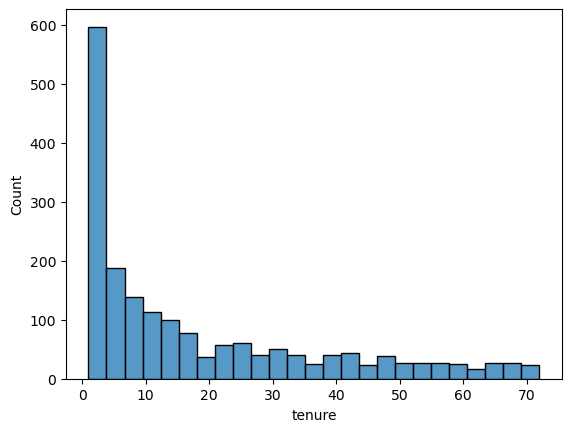

In [78]:
tenure_churn = df[df['churn'] ==1].tenure
sns.histplot(tenure_churn, bins = 25)

In [79]:
df.groupby(['tenure']).agg({'churn':'mean'})

,churn
tenure,
0,0.000000
1,0.619902
2,0.516807
3,0.470000
4,0.471591
...,...
68,0.090000
69,0.084211
70,0.092437


Customers who have tenure less than or equal to 2 tend to churn

C:\Users\v121256\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Distribution of Mothly Charges of Churned customers')

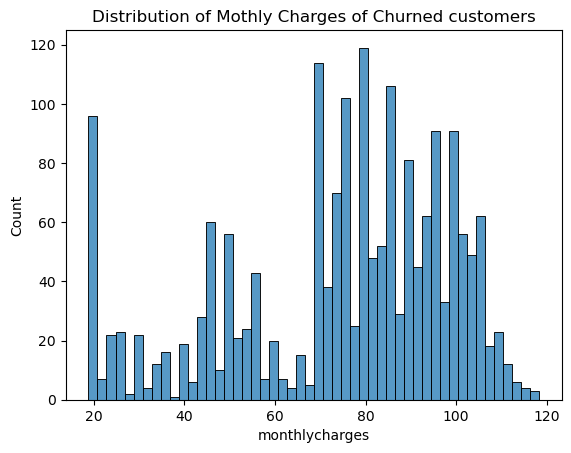

In [80]:
monthlycharge_churn = df[df['churn'] ==1].monthlycharges 
sns.histplot(monthlycharge_churn, bins = 50)
plt.title('Distribution of Mothly Charges of Churned customers')

we can observe that the group of customers with the highest likelihood to churn belongs to the group with monthly charges greater than $50

**Categorical variables analysis**

In [81]:
categorical_var = df.select_dtypes(include =['object'])
categorical_var.nunique()

customerid          7043
gender                 2
seniorcitizen          2
partner                2
dependents             2
phoneservice           2
multiplelines          3
internetservice        3
onlinesecurity         3
onlinebackup           3
deviceprotection       3
techsupport            3
streamingtv            3
streamingmovies        3
contract               3
paperlessbilling       2
paymentmethod          4
dtype: int64

In [82]:
df_cat = list(df.dtypes[df.dtypes == 'object'].index)
for i in df_cat:
    if i != 'customerid':
        df_group= pd.DataFrame(df.groupby([i]).churn.agg(['mean']))
        df_group['risk_ratio'] = df_group['mean']/ global_churn_rate
        display(df_group)
        

,mean,risk_ratio
gender,,
female,0.269209,1.014466
male,0.261603,0.985807


,mean,risk_ratio
seniorcitizen,,
0,0.236062,0.889557
1,0.416813,1.570686


,mean,risk_ratio
partner,,
no,0.329580,1.241964
yes,0.196649,0.741038


,mean,risk_ratio
dependents,,
no,0.312791,1.178700
yes,0.154502,0.582215


,mean,risk_ratio
phoneservice,,
no,0.249267,0.939319
yes,0.267096,1.006506


...

,mean,risk_ratio
streamingtv,,
no,0.335231,1.263261
no_internet_service,0.074050,0.279044
yes,0.300702,1.133143


,mean,risk_ratio
streamingmovies,,
no,0.336804,1.269188
no_internet_service,0.074050,0.279044
yes,0.299414,1.128291


,mean,risk_ratio
contract,,
month-to-month,0.427097,1.609440
one_year,0.112695,0.424672
two_year,0.028319,0.106714


,mean,risk_ratio
paperlessbilling,,
no,0.163301,0.615371
yes,0.335651,1.264842


,mean,risk_ratio
paymentmethod,,
bank_transfer_(automatic),0.167098,0.629681
credit_card_(automatic),0.152431,0.574410
electronic_check,0.452854,1.706502
mailed_check,0.191067,0.720003


In [83]:
#calculate mutual infor score
def mutual_info_churn_score(series):
    return mutual_info_score(series, df.churn)
mi = df[df_cat].apply(mutual_info_churn_score)

In [84]:
mi.sort_values(ascending = False)

customerid          0.578599
contract            0.098453
onlinesecurity      0.064677
techsupport         0.063021
internetservice     0.055574
onlinebackup        0.046792
paymentmethod       0.044519
deviceprotection    0.043917
streamingmovies     0.032001
streamingtv         0.031908
paperlessbilling    0.019194
dependents          0.014467
partner             0.011454
seniorcitizen       0.010577
multiplelines       0.000801
phoneservice        0.000072
gender              0.000037
dtype: float64

## 3. Processing Data

### 3.1 Categorical data encoding

In [85]:
df_cat.remove('customerid')

In [86]:
#Using One hot encoder to transform categorical features
encoder = OneHotEncoder(sparse =False)
encoder_array = encoder.fit_transform(df[df_cat])
encoder_df = pd.DataFrame(encoder_array, columns = encoder.get_feature_names_out(df_cat))
encoder_df

C:\Users\v121256\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


,gender_female,gender_male,seniorcitizen_0,seniorcitizen_1,partner_no,partner_yes,dependents_no,dependents_yes,phoneservice_no,phoneservice_yes,...,streamingmovies_yes,contract_month-to-month,contract_one_year,contract_two_year,paperlessbilling_no,paperlessbilling_yes,paymentmethod_bank_transfer_(automatic),paymentmethod_credit_card_(automatic),paymentmethod_electronic_check,paymentmethod_mailed_check
0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
7039,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
7040,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7041,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [87]:
combine_df = pd.concat([encoder_df, df_numerical_var], axis = 1)

### 3.2 Spliting data

In [88]:
y_target = combine_df.churn
X_feature = combine_df.drop('churn', axis =1)

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X_feature,y_target,test_size = 0.2, random_state = 42)

In [90]:
print('Training features shape:', X_train.shape)
print('Training target shape:', y_train.shape)
print('Test features shape:', X_test.shape)
print('Test target shape:', y_test.shape)

Training features shape: (5634, 46)
Training target shape: (5634,)
Test features shape: (1409, 46)
Test target shape: (1409,)


## 4.Model implementing 

In [92]:
logistic_model = LogisticRegression(solver='lbfgs')
logistic_model.fit(X_train, y_train)


C:\Users\v121256\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [116]:
#Result of Train set 
y_train_pred = logistic_model.predict(X_train)
train_acc = round(accuracy_score(y_train_pred, y_train),2)
train_precision = round(precision_score(y_train_pred, y_train),2)
train_recall = round(recall_score(y_train_pred, y_train),2)

In [117]:
print('Train_set_Accuracy: ',train_acc)
print('Train_set_Precision ',train_precision)
print('Train_set_Recal: ', train_recall)

Train_set_Accuracy:  0.8
Train_set_Precision  0.54
Train_set_Recal:  0.66


In [118]:
y_test_pred = logistic_model.predict(X_test)
test_acc = round(accuracy_score(y_test_pred, y_test),2)
test_precision = round(precision_score(y_test_pred, y_test),2)
test_recall = round(precision_score(y_test_pred, y_test),2)

In [119]:
print('Train_set_Accuracy: ',test_acc)
print('Train_set_Precision: ',test_precision)
print('Train_set_Recal: ', test_recall)

Train_set_Accuracy:  0.82
Train_set_Precision:  0.58
Train_set_Recal:  0.58
